In [17]:
# CELL 1 — Imports + GPU + seed

import os
import json
import copy
import time
import random
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix
)

# =========================================================
# Reproducibility
# =========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# =========================================================
# Device
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


CELL 2 — Paths + saving folders

In [18]:
# =========================================================
# Original dataset
# =========================================================

AUTHENTIC_PATH = (
    "/kaggle/input/datasets/saikotahmed/"
    "imd2020/IMD2020/Authentic"
)

IMG_PATH = (
    "/kaggle/input/datasets/saikotahmed/"
    "imd2020/IMD2020/img"
)

MASK_PATH = (
    "/kaggle/input/datasets/saikotahmed/"
    "imd2020/IMD2020/mask"
)


# =========================================================
# Standardized dataset
# =========================================================

STANDARD_PATH = (
    "/kaggle/working/IMD2020_standardized"
)

STANDARD_AUTHENTIC_PATH = os.path.join(
    STANDARD_PATH,
    "Authentic"
)

STANDARD_FORGED_PATH = os.path.join(
    STANDARD_PATH,
    "Forged"
)


# =========================================================
# SusLens experiment output folder
# =========================================================

RESULTS_PATH = (
    "/kaggle/working/SusLens_Results"
)


# Create folders

os.makedirs(
    STANDARD_AUTHENTIC_PATH,
    exist_ok=True
)

os.makedirs(
    STANDARD_FORGED_PATH,
    exist_ok=True
)

os.makedirs(
    RESULTS_PATH,
    exist_ok=True
)


print("All paths ready.")
print("Results will be saved to:")
print(RESULTS_PATH)

All paths ready.
Results will be saved to:
/kaggle/working/SusLens_Results


CELL 3 — Standardize images

In [19]:
def standardize_images(
    input_folder,
    output_folder
):

    files = [
        f
        for f in os.listdir(input_folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    for file in files:

        input_path = os.path.join(
            input_folder,
            file
        )

        output_name = (
            os.path.splitext(file)[0]
            + ".jpg"
        )

        output_path = os.path.join(
            output_folder,
            output_name
        )

        # Skip if already converted
        if os.path.exists(output_path):
            continue

        image = (
            Image.open(input_path)
            .convert("RGB")
        )

        image.save(
            output_path,
            format="JPEG",
            quality=95
        )

    return len(files)


# Authentic

authentic_count = standardize_images(
    AUTHENTIC_PATH,
    STANDARD_AUTHENTIC_PATH
)


# Forged

forged_count = standardize_images(
    IMG_PATH,
    STANDARD_FORGED_PATH
)


print(
    "Authentic images:",
    authentic_count
)

print(
    "Forged images:",
    forged_count
)

Authentic images: 414
Forged images: 2010


CELL 4 — Build dataframe

In [20]:
data = []


# =========================================================
# Authentic = 0
# =========================================================

for file in os.listdir(
    STANDARD_AUTHENTIC_PATH
):

    if file.lower().endswith(".jpg"):

        data.append({
            "image_path": os.path.join(
                STANDARD_AUTHENTIC_PATH,
                file
            ),
            "label": 0
        })


# =========================================================
# Forged = 1
# =========================================================

for file in os.listdir(
    STANDARD_FORGED_PATH
):

    if file.lower().endswith(".jpg"):

        data.append({
            "image_path": os.path.join(
                STANDARD_FORGED_PATH,
                file
            ),
            "label": 1
        })


standard_df = pd.DataFrame(data)


print(
    "Total images:",
    len(standard_df)
)

print("\nClass distribution:")

print(
    standard_df["label"]
    .value_counts()
    .sort_index()
)

Total images: 2424

Class distribution:
label
0     414
1    2010
Name: count, dtype: int64


CELL 5 — Train / validation / test split

In [21]:
# Shuffle once with fixed seed

standard_df = (
    standard_df
    .sample(
        frac=1,
        random_state=SEED
    )
    .reset_index(drop=True)
)


# =========================================================
# 80% train / 20% temporary
# =========================================================

train_df, temp_df = train_test_split(
    standard_df,
    test_size=0.20,
    stratify=standard_df["label"],
    random_state=SEED
)


# =========================================================
# 10% validation / 10% test
# =========================================================

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)


print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


print("\nTrain:")
print(train_df["label"].value_counts())


print("\nValidation:")
print(val_df["label"].value_counts())


print("\nTest:")
print(test_df["label"].value_counts())

Train: 1939
Validation: 242
Test: 243

Train:
label
1    1608
0     331
Name: count, dtype: int64

Validation:
label
1    201
0     41
Name: count, dtype: int64

Test:
label
1    201
0     42
Name: count, dtype: int64


CELL 6 — Transforms

In [22]:
PATCH_SIZE = 224
PATCHES_PER_IMAGE = 2


# =========================================================
# Training transform
# =========================================================

patch_train_transform = transforms.Compose([

    transforms.Resize(256),

    transforms.RandomCrop(224),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# =========================================================
# Validation / test transform
# =========================================================

patch_test_transform = transforms.Compose([

    transforms.Resize(256),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


print("Transforms ready.")

Transforms ready.


CELL 7 — Mask-guided patch dataset

In [23]:
def get_mask_path(image_path):

    filename = os.path.basename(
        image_path
    )

    base_name = os.path.splitext(
        filename
    )[0]

    # Convert standardized path
    # to original IMD image folder

    original_image_path = image_path.replace(
        STANDARD_FORGED_PATH,
        IMG_PATH
    )

    original_filename = os.path.basename(
        original_image_path
    )

    original_base = os.path.splitext(
        original_filename
    )[0]

    return os.path.join(
        MASK_PATH,
        original_base + "_mask.png"
    )


class MaskGuidedPatchDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.transform = transform

        self.samples = []


        # =================================================
        # Prepare samples
        # =================================================

        for _, row in self.dataframe.iterrows():

            image_path = row["image_path"]

            label = row["label"]


            # ---------------------------------------------
            # Authentic
            # ---------------------------------------------

            if label == 0:

                self.samples.append({
                    "image_path": image_path,
                    "label": 0,
                    "box": None
                })


            # ---------------------------------------------
            # Forged
            # ---------------------------------------------

            else:

                mask_path = get_mask_path(
                    image_path
                )


                if not os.path.exists(
                    mask_path
                ):
                    continue


                mask = np.array(
                    Image.open(
                        mask_path
                    ).convert("L")
                )


                ys, xs = np.where(
                    mask > 0
                )


                if len(xs) == 0:
                    continue


                x_min = xs.min()
                x_max = xs.max()

                y_min = ys.min()
                y_max = ys.max()


                self.samples.append({
                    "image_path": image_path,
                    "label": 1,
                    "box": (
                        x_min,
                        y_min,
                        x_max,
                        y_max
                    )
                })


    def __len__(self):

        return (
            len(self.samples)
            * PATCHES_PER_IMAGE
        )


    def __getitem__(self, index):

        image_index = (
            index // PATCHES_PER_IMAGE
        )

        sample = self.samples[
            image_index
        ]


        image = (
            Image.open(
                sample["image_path"]
            )
            .convert("RGB")
        )


        # =================================================
        # Authentic → random crop
        # =================================================

        if sample["label"] == 0:

            width, height = image.size


            if (
                width < PATCH_SIZE
                or height < PATCH_SIZE
            ):

                image = image.resize(
                    (256, 256)
                )

                width, height = image.size


            max_x = width - PATCH_SIZE
            max_y = height - PATCH_SIZE


            x = np.random.randint(
                0,
                max_x + 1
            )

            y = np.random.randint(
                0,
                max_y + 1
            )


        # =================================================
        # Forged → mask-guided crop
        # =================================================

        else:

            (
                x_min,
                y_min,
                x_max,
                y_max
            ) = sample["box"]


            center_x = (
                x_min + x_max
            ) // 2

            center_y = (
                y_min + y_max
            ) // 2


            width, height = image.size


            if (
                width < PATCH_SIZE
                or height < PATCH_SIZE
            ):

                image = image.resize(
                    (256, 256)
                )

                width, height = image.size


            x = max(
                0,
                min(
                    center_x
                    - PATCH_SIZE // 2,
                    width - PATCH_SIZE
                )
            )


            y = max(
                0,
                min(
                    center_y
                    - PATCH_SIZE // 2,
                    height - PATCH_SIZE
                )
            )


        # =================================================
        # Crop
        # =================================================

        image = image.crop(
            (
                x,
                y,
                x + PATCH_SIZE,
                y + PATCH_SIZE
            )
        )


        # =================================================
        # Transform
        # =================================================

        if self.transform:

            image = self.transform(
                image
            )


        return image, sample["label"]


print("Dataset class ready.")

Dataset class ready.


In [24]:
# Recreate the mask-guided test dataset
mask_patch_test_dataset = MaskGuidedPatchDataset(
    test_df,
    transform=patch_test_transform
)

print("Mask-guided test dataset ready.")
print("Test patches:", len(mask_patch_test_dataset))

Mask-guided test dataset ready.
Test patches: 486


In [25]:
from torch.utils.data import DataLoader

mask_patch_test_loader = DataLoader(
    mask_patch_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("Mask-guided test loader ready.")
print("Number of test patches:", len(mask_patch_test_dataset))

Mask-guided test loader ready.
Number of test patches: 486


CELL 8 — DataLoaders

In [26]:
# =========================================================
# Dataset objects
# =========================================================

train_dataset = MaskGuidedPatchDataset(
    train_df,
    transform=patch_train_transform
)

val_dataset = MaskGuidedPatchDataset(
    val_df,
    transform=patch_test_transform
)

test_dataset = MaskGuidedPatchDataset(
    test_df,
    transform=patch_test_transform
)


# =========================================================
# DataLoaders
# =========================================================

BATCH_SIZE = 32


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print(
    "Train patches:",
    len(train_dataset)
)

print(
    "Validation patches:",
    len(val_dataset)
)

print(
    "Test patches:",
    len(test_dataset)
)

Train patches: 3878
Validation patches: 484
Test patches: 486


CELL 9 — Model factory

In [ ]:
def create_model(model_name):

    # =====================================================
    # ResNet50
    # =====================================================

    if model_name == "resnet50":

        model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            2
        )


    # =====================================================
    # EfficientNet-B0
    # =====================================================

    elif model_name == "efficientnet_b0":

        model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            2
        )


    # =====================================================
    # DenseNet121
    # =====================================================

    elif model_name == "densenet121":

        model = models.densenet121(
            weights=models.DenseNet121_Weights.DEFAULT
        )

        model.classifier = nn.Linear(
            model.classifier.in_features,
            2
        )


    # =====================================================
    # ConvNeXt-Tiny
    # =====================================================

    elif model_name == "convnext_tiny":

        model = models.convnext_tiny(
            weights=models.ConvNeXt_Tiny_Weights.DEFAULT
        )

        model.classifier[2] = nn.Linear(
            model.classifier[2].in_features,
            2
        )


    # =====================================================
    # ViT-B/16
    # =====================================================

    elif model_name == "vit_b_16":

        model = models.vit_b_16(
            weights=models.ViT_B_16_Weights.DEFAULT
        )

        model.heads.head = nn.Linear(
            model.heads.head.in_features,
            2
        )


    # =====================================================
    # MobileNetV3-Large
    # =====================================================

    elif model_name == "mobilenet_v3_large":

        model = models.mobilenet_v3_large(
            weights=models.MobileNet_V3_Large_Weights.DEFAULT
        )

        model.classifier[3] = nn.Linear(
            model.classifier[3].in_features,
            2
        )


    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )


    return model.to(device)


print("Model factory ready.")

CELL 10 — Generic Training Function

In [ ]:
# ============================================================
# CELL 10 — RESNET50 TRAINING — 50 EPOCHS
# ============================================================

import time
import copy

print("=" * 70)
print("STARTING RESNET50 TRAINING")
print("=" * 70)

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

EPOCHS = 50

# ------------------------------------------------------------
# Create model using Cell 9 factory
# ------------------------------------------------------------

model = create_model("resnet50")

# ------------------------------------------------------------
# Class weights
# ------------------------------------------------------------

class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

class_weights = (
    len(train_df) /
    (2 * class_counts.values)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# ------------------------------------------------------------
# Checkpoint
# ------------------------------------------------------------

checkpoint_path = os.path.join(
    RESULTS_PATH,
    "resnet50_best.pth"
)

best_val_f1 = 0.0
best_epoch = 0

start_time = time.time()

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

for epoch in range(EPOCHS):

    model.train()

    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_total += labels.size(0)

        train_correct += (
            predictions == labels
        ).sum().item()

    train_accuracy = (
        train_correct / train_total
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model.eval()

    val_labels = []
    val_predictions = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            ).cpu().numpy()

            val_labels.extend(
                labels.numpy()
            )

            val_predictions.extend(
                predictions
            )

    val_accuracy = accuracy_score(
        val_labels,
        val_predictions
    )

    val_precision = precision_score(
        val_labels,
        val_predictions,
        zero_division=0
    )

    val_recall = recall_score(
        val_labels,
        val_predictions,
        zero_division=0
    )

    val_f1 = f1_score(
        val_labels,
        val_predictions,
        zero_division=0
    )

    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        best_epoch = epoch + 1

        torch.save(
            {
                "model_name": "resnet50",
                "epoch": best_epoch,
                "best_val_f1": best_val_f1,
                "model_state_dict": copy.deepcopy(
                    model.state_dict()
                )
            },
            checkpoint_path
        )

        saved = "✓ CHECKPOINT SAVED"

    else:
        saved = ""

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val F1: {val_f1:.4f} "
        f"{saved}"
    )

# ------------------------------------------------------------
# Finished
# ------------------------------------------------------------

training_time = time.time() - start_time

print("\n" + "=" * 70)
print("RESNET50 TRAINING COMPLETED")
print("=" * 70)

print(f"Best Validation F1 : {best_val_f1:.4f}")
print(f"Best Epoch         : {best_epoch}")
print(
    f"Training Time      : "
    f"{training_time / 60:.2f} minutes"
)
print(f"Checkpoint saved   : {checkpoint_path}")
print("=" * 70)

# CELL 11 — ResNet50 Test Evaluation

In [ ]:
# ============================================================
# CELL 11 — RESNET50 TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix
)

print("=" * 70)
print("LOADING BEST RESNET50 CHECKPOINT")
print("=" * 70)

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    "/kaggle/working/SusLens_Results/resnet50_best.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

print(
    f"Best Epoch: {checkpoint['epoch']}"
)

print(
    f"Best Validation F1: "
    f"{checkpoint['best_val_f1']:.4f}"
)

# ------------------------------------------------------------
# Test prediction
# ------------------------------------------------------------

test_labels = []
test_predictions = []
test_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        test_labels.extend(
            labels.numpy()
        )

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        # Probability of class 1 = Forged
        test_probabilities.extend(
            probabilities[:, 1]
            .cpu()
            .numpy()
        )

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_precision = precision_score(
    test_labels,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    test_labels,
    test_predictions,
    zero_division=0
)

test_macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

test_balanced_accuracy = balanced_accuracy_score(
    test_labels,
    test_predictions
)

test_auc = roc_auc_score(
    test_labels,
    test_probabilities
)

cm = confusion_matrix(
    test_labels,
    test_predictions
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RESNET50 TEST RESULTS")
print("=" * 70)

print(f"Accuracy           : {test_accuracy:.4f}")
print(f"Precision          : {test_precision:.4f}")
print(f"Forged Recall      : {test_recall:.4f}")
print(f"F1 Score           : {test_f1:.4f}")
print(f"Macro F1           : {test_macro_f1:.4f}")
print(f"Balanced Accuracy  : {test_balanced_accuracy:.4f}")
print(f"ROC-AUC            : {test_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("=" * 70)

# ------------------------------------------------------------
# Save test results
# ------------------------------------------------------------

resnet_test_results = {
    "model_name": "resnet50",
    "best_epoch": checkpoint["epoch"],
    "best_val_f1": checkpoint["best_val_f1"],
    "test_accuracy": test_accuracy,
    "test_precision": test_precision,
    "test_forged_recall": test_recall,
    "test_f1": test_f1,
    "test_macro_f1": test_macro_f1,
    "test_balanced_accuracy": test_balanced_accuracy,
    "test_roc_auc": test_auc,
    "confusion_matrix": cm.tolist()
}

with open(
    "/kaggle/working/SusLens_Results/resnet50_test_results.json",
    "w"
) as f:

    json.dump(
        resnet_test_results,
        f,
        indent=4
    )

print(
    "\n✓ Test results saved successfully."
)

# Cell 12 : EFFICIENTNET-B0 TRAIN + TEST


In [ ]:
# ============================================================
# CELL 12 — EFFICIENTNET-B0 TRAIN + TEST — 50 EPOCHS
# ============================================================

import time
import copy
import json

print("=" * 70)
print("STARTING EFFICIENTNET-B0")
print("=" * 70)

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

EPOCHS = 50

# ------------------------------------------------------------
# 1. Create model
# ------------------------------------------------------------

model = create_model("efficientnet_b0")

# ------------------------------------------------------------
# 2. Class weights
# ------------------------------------------------------------

class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

class_weights = (
    len(train_df)
    / (2 * class_counts.values)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# ------------------------------------------------------------
# 3. Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# ------------------------------------------------------------
# 4. Checkpoint
# ------------------------------------------------------------

checkpoint_path = os.path.join(
    RESULTS_PATH,
    "efficientnet_b0_best.pth"
)

best_val_f1 = 0.0
best_epoch = 0

start_time = time.time()

# ------------------------------------------------------------
# 5. Training
# ------------------------------------------------------------

for epoch in range(EPOCHS):

    model.train()

    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_total += labels.size(0)

        train_correct += (
            predictions == labels
        ).sum().item()

    train_accuracy = (
        train_correct / train_total
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model.eval()

    val_labels = []
    val_predictions = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            ).cpu().numpy()

            val_labels.extend(
                labels.numpy()
            )

            val_predictions.extend(
                predictions
            )

    val_accuracy = accuracy_score(
        val_labels,
        val_predictions
    )

    val_precision = precision_score(
        val_labels,
        val_predictions,
        zero_division=0
    )

    val_recall = recall_score(
        val_labels,
        val_predictions,
        zero_division=0
    )

    val_f1 = f1_score(
        val_labels,
        val_predictions,
        zero_division=0
    )

    # --------------------------------------------------------
    # Save best checkpoint
    # --------------------------------------------------------

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        best_epoch = epoch + 1

        torch.save(
            {
                "model_name": "efficientnet_b0",
                "epoch": best_epoch,
                "best_val_f1": best_val_f1,
                "model_state_dict": copy.deepcopy(
                    model.state_dict()
                )
            },
            checkpoint_path
        )

        saved = "✓ CHECKPOINT SAVED"

    else:
        saved = ""

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val F1: {val_f1:.4f} "
        f"{saved}"
    )

# ------------------------------------------------------------
# 6. Training completed
# ------------------------------------------------------------

training_time = time.time() - start_time

print("\n" + "=" * 70)
print("EFFICIENTNET-B0 TRAINING COMPLETED")
print("=" * 70)

print(f"Best Validation F1 : {best_val_f1:.4f}")
print(f"Best Epoch         : {best_epoch}")
print(
    f"Training Time      : "
    f"{training_time / 60:.2f} minutes"
)
print(f"Checkpoint         : {checkpoint_path}")

# ------------------------------------------------------------
# 7. Load BEST checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

# ------------------------------------------------------------
# 8. Test evaluation
# ------------------------------------------------------------

test_labels = []
test_predictions = []
test_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        test_labels.extend(
            labels.numpy()
        )

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_probabilities.extend(
            probabilities[:, 1]
            .cpu()
            .numpy()
        )

# ------------------------------------------------------------
# 9. Metrics
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_precision = precision_score(
    test_labels,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    test_labels,
    test_predictions,
    zero_division=0
)

test_macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

test_balanced_accuracy = balanced_accuracy_score(
    test_labels,
    test_predictions
)

test_auc = roc_auc_score(
    test_labels,
    test_probabilities
)

cm = confusion_matrix(
    test_labels,
    test_predictions
)

# ------------------------------------------------------------
# 10. Display results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EFFICIENTNET-B0 TEST RESULTS")
print("=" * 70)

print(f"Accuracy           : {test_accuracy:.4f}")
print(f"Precision          : {test_precision:.4f}")
print(f"Forged Recall      : {test_recall:.4f}")
print(f"F1 Score           : {test_f1:.4f}")
print(f"Macro F1           : {test_macro_f1:.4f}")
print(f"Balanced Accuracy  : {test_balanced_accuracy:.4f}")
print(f"ROC-AUC            : {test_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("=" * 70)

# ------------------------------------------------------------
# 11. Save results
# ------------------------------------------------------------

efficientnet_test_results = {
    "model_name": "efficientnet_b0",
    "best_epoch": checkpoint["epoch"],
    "best_val_f1": checkpoint["best_val_f1"],
    "test_accuracy": test_accuracy,
    "test_precision": test_precision,
    "test_forged_recall": test_recall,
    "test_f1": test_f1,
    "test_macro_f1": test_macro_f1,
    "test_balanced_accuracy": test_balanced_accuracy,
    "test_roc_auc": test_auc,
    "confusion_matrix": cm.tolist()
}

with open(
    "/kaggle/working/SusLens_Results/"
    "efficientnet_b0_test_results.json",
    "w"
) as f:

    json.dump(
        efficientnet_test_results,
        f,
        indent=4
    )

print("\n✓ EfficientNet-B0 checkpoint saved.")
print("✓ EfficientNet-B0 test results saved.")

# ------------------------------------------------------------
# 12. Free GPU memory
# ------------------------------------------------------------

del model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✓ GPU memory cleared.")

# Cell 13 — DenseNet121: Train + Test

In [ ]:
# ============================================================
# DENSENET121 — 50 EPOCH TRAIN + TEST
# ============================================================

import time
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix
)

MODEL_NAME = "densenet121"

print("=" * 60)
print("STARTING DENSENET121")
print("=" * 60)

# ============================================================
# CREATE MODEL
# ============================================================

model = create_model(MODEL_NAME)


# ============================================================
# CLASS WEIGHTS
# ============================================================

class_counts = train_df["label"].value_counts().sort_index().values

class_weights = len(train_df) / (2 * class_counts)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


# ============================================================
# TRAINING SETTINGS
# ============================================================

EPOCHS = 50

best_val_f1 = 0.0
best_epoch = 0

checkpoint_path = (
    "/kaggle/working/SusLens_Results/"
    "densenet121_best.pth"
)

start_time = time.time()


# ============================================================
# TRAINING
# ============================================================

for epoch in range(EPOCHS):

    model.train()

    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        predictions = outputs.argmax(
            dim=1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

    train_acc = train_correct / train_total


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_labels = []
    val_predictions = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(
                dim=1
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

            val_predictions.extend(
                predictions.cpu().numpy()
            )


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_acc = accuracy_score(
        val_labels,
        val_predictions
    )

    val_precision = precision_score(
        val_labels,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_recall = recall_score(
        val_labels,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_f1 = f1_score(
        val_labels,
        val_predictions,
        pos_label=1,
        zero_division=0
    )


    # ========================================================
    # SAVE BEST CHECKPOINT
    # ========================================================

    checkpoint_text = ""

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            checkpoint_path
        )

        checkpoint_text = " ✓ CHECKPOINT SAVED"


    # ========================================================
    # PRINT EPOCH RESULTS
    # ========================================================

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val F1: {val_f1:.4f}"
        f"{checkpoint_text}"
    )


# ============================================================
# TRAINING COMPLETED
# ============================================================

training_time = (
    time.time() - start_time
) / 60

print()
print("=" * 60)
print("DENSENET121 TRAINING COMPLETED")
print("=" * 60)

print(
    f"Best Validation F1 : {best_val_f1:.4f}"
)

print(
    f"Best Epoch         : {best_epoch}"
)

print(
    f"Training Time      : {training_time:.2f} minutes"
)

print(
    f"Checkpoint         : {checkpoint_path}"
)


# ============================================================
# LOAD BEST MODEL
# ============================================================

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

model.eval()


# ============================================================
# TEST
# ============================================================

test_labels = []
test_predictions = []
test_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        predictions = outputs.argmax(
            dim=1
        )

        test_labels.extend(
            labels.cpu().numpy()
        )

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_probabilities.extend(
            probabilities.cpu().numpy()
        )


# ============================================================
# TEST METRICS
# ============================================================

accuracy = accuracy_score(
    test_labels,
    test_predictions
)

precision = precision_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

balanced_acc = balanced_accuracy_score(
    test_labels,
    test_predictions
)

roc_auc = roc_auc_score(
    test_labels,
    test_probabilities
)

cm = confusion_matrix(
    test_labels,
    test_predictions
)


# ============================================================
# PRINT TEST RESULTS
# ============================================================

print()
print("=" * 60)
print("DENSENET121 TEST RESULTS")
print("=" * 60)

print(
    f"Accuracy           : {accuracy:.4f}"
)

print(
    f"Precision          : {precision:.4f}"
)

print(
    f"Forged Recall      : {recall:.4f}"
)

print(
    f"F1 Score           : {f1:.4f}"
)

print(
    f"Macro F1           : {macro_f1:.4f}"
)

print(
    f"Balanced Accuracy  : {balanced_acc:.4f}"
)

print(
    f"ROC-AUC            : {roc_auc:.4f}"
)

print()
print("Confusion Matrix:")
print(cm)


# ============================================================
# SAVE TEST RESULTS
# ============================================================

results = {
    "model": MODEL_NAME,
    "best_validation_f1": best_val_f1,
    "best_epoch": best_epoch,
    "training_time_minutes": training_time,
    "accuracy": accuracy,
    "precision": precision,
    "forged_recall": recall,
    "f1": f1,
    "macro_f1": macro_f1,
    "balanced_accuracy": balanced_acc,
    "roc_auc": roc_auc,
    "confusion_matrix": cm.tolist()
}

results_path = (
    "/kaggle/working/SusLens_Results/"
    "densenet121_test_results.json"
)

with open(
    results_path,
    "w"
) as f:

    json.dump(
        results,
        f,
        indent=4
    )


# ============================================================
# CLEANUP
# ============================================================

print()
print("✓ DenseNet121 checkpoint saved.")
print("✓ DenseNet121 test results saved.")

del model

torch.cuda.empty_cache()

print("✓ GPU memory cleared.")

# Cell 14 — ConvNeXt-Tiny: Train + Test

In [ ]:
# ============================================================
# CONVNEXT-TINY — 50 EPOCH TRAIN + TEST
# ============================================================

import time
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix
)

MODEL_NAME = "convnext_tiny"

print("=" * 60)
print("STARTING CONVNEXT-TINY")
print("=" * 60)


# ============================================================
# CREATE MODEL
# ============================================================

model = create_model(MODEL_NAME)


# ============================================================
# CLASS WEIGHTS
# ============================================================

class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
    .values
)

class_weights = (
    len(train_df) /
    (2 * class_counts)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


# ============================================================
# TRAINING SETTINGS
# ============================================================

EPOCHS = 50

best_val_f1 = 0.0
best_epoch = 0

checkpoint_path = (
    "/kaggle/working/SusLens_Results/"
    "convnext_tiny_best.pth"
)

start_time = time.time()


# ============================================================
# TRAINING
# ============================================================

for epoch in range(EPOCHS):

    model.train()

    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        predictions = outputs.argmax(
            dim=1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

    train_acc = (
        train_correct /
        train_total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_labels = []
    val_predictions = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(
                dim=1
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

            val_predictions.extend(
                predictions.cpu().numpy()
            )


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_acc = accuracy_score(
        val_labels,
        val_predictions
    )

    val_precision = precision_score(
        val_labels,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_recall = recall_score(
        val_labels,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_f1 = f1_score(
        val_labels,
        val_predictions,
        pos_label=1,
        zero_division=0
    )


    # ========================================================
    # SAVE BEST CHECKPOINT
    # ========================================================

    checkpoint_text = ""

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            checkpoint_path
        )

        checkpoint_text = (
            " ✓ CHECKPOINT SAVED"
        )


    # ========================================================
    # PRINT EPOCH RESULTS
    # ========================================================

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val F1: {val_f1:.4f}"
        f"{checkpoint_text}"
    )


# ============================================================
# TRAINING COMPLETED
# ============================================================

training_time = (
    time.time() - start_time
) / 60

print()
print("=" * 60)
print("CONVNEXT-TINY TRAINING COMPLETED")
print("=" * 60)

print(
    f"Best Validation F1 : "
    f"{best_val_f1:.4f}"
)

print(
    f"Best Epoch         : "
    f"{best_epoch}"
)

print(
    f"Training Time      : "
    f"{training_time:.2f} minutes"
)

print(
    f"Checkpoint         : "
    f"{checkpoint_path}"
)


# ============================================================
# LOAD BEST MODEL
# ============================================================

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

model.eval()


# ============================================================
# TEST
# ============================================================

test_labels = []
test_predictions = []
test_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        predictions = outputs.argmax(
            dim=1
        )

        test_labels.extend(
            labels.cpu().numpy()
        )

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_probabilities.extend(
            probabilities.cpu().numpy()
        )


# ============================================================
# TEST METRICS
# ============================================================

accuracy = accuracy_score(
    test_labels,
    test_predictions
)

precision = precision_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

balanced_acc = balanced_accuracy_score(
    test_labels,
    test_predictions
)

roc_auc = roc_auc_score(
    test_labels,
    test_probabilities
)

cm = confusion_matrix(
    test_labels,
    test_predictions
)


# ============================================================
# PRINT TEST RESULTS
# ============================================================

print()
print("=" * 60)
print("CONVNEXT-TINY TEST RESULTS")
print("=" * 60)

print(
    f"Accuracy           : "
    f"{accuracy:.4f}"
)

print(
    f"Precision          : "
    f"{precision:.4f}"
)

print(
    f"Forged Recall      : "
    f"{recall:.4f}"
)

print(
    f"F1 Score           : "
    f"{f1:.4f}"
)

print(
    f"Macro F1           : "
    f"{macro_f1:.4f}"
)

print(
    f"Balanced Accuracy  : "
    f"{balanced_acc:.4f}"
)

print(
    f"ROC-AUC            : "
    f"{roc_auc:.4f}"
)

print()
print("Confusion Matrix:")
print(cm)


# ============================================================
# SAVE RESULTS
# ============================================================

results = {
    "model": MODEL_NAME,
    "best_validation_f1": best_val_f1,
    "best_epoch": best_epoch,
    "training_time_minutes": training_time,
    "accuracy": accuracy,
    "precision": precision,
    "forged_recall": recall,
    "f1": f1,
    "macro_f1": macro_f1,
    "balanced_accuracy": balanced_acc,
    "roc_auc": roc_auc,
    "confusion_matrix": cm.tolist()
}

results_path = (
    "/kaggle/working/SusLens_Results/"
    "convnext_tiny_test_results.json"
)

with open(
    results_path,
    "w"
) as f:

    json.dump(
        results,
        f,
        indent=4
    )


# ============================================================
# CLEANUP
# ============================================================

print()
print("✓ ConvNeXt-Tiny checkpoint saved.")
print("✓ ConvNeXt-Tiny test results saved.")

del model

torch.cuda.empty_cache()

print("✓ GPU memory cleared.")

# Cell 15 — ViT-B/16: Train + Test


In [ ]:
# ============================================================
# ViT-B/16 — 50 EPOCH TRAIN + TEST
# ============================================================

import time
import json
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix
)

MODEL_NAME = "vit_b_16"

print("=" * 60)
print("STARTING ViT-B/16")
print("=" * 60)

# ============================================================
# CREATE MODEL
# ============================================================

model = create_model(MODEL_NAME)

# ============================================================
# CLASS WEIGHTS
# ============================================================

class_counts = train_df["label"].value_counts().sort_index().values

class_weights = len(train_df) / (2 * class_counts)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# ============================================================
# TRAINING SETTINGS
# ============================================================

EPOCHS = 50

best_val_f1 = 0.0
best_epoch = 0

checkpoint_path = (
    "/kaggle/working/SusLens_Results/"
    "vit_b_16_best.pth"
)

start_time = time.time()

# ============================================================
# TRAINING
# ============================================================

for epoch in range(EPOCHS):

    model.train()

    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        predictions = outputs.argmax(dim=1)

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

    train_acc = train_correct / train_total

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_labels = []
    val_predictions = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            val_labels.extend(
                labels.cpu().numpy()
            )

            val_predictions.extend(
                predictions.cpu().numpy()
            )

    val_acc = accuracy_score(
        val_labels,
        val_predictions
    )

    val_precision = precision_score(
        val_labels,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_recall = recall_score(
        val_labels,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_f1 = f1_score(
        val_labels,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    # ========================================================
    # SAVE BEST CHECKPOINT
    # ========================================================

    checkpoint_text = ""

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            checkpoint_path
        )

        checkpoint_text = " ✓ CHECKPOINT SAVED"

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val F1: {val_f1:.4f}"
        f"{checkpoint_text}"
    )


training_time = (time.time() - start_time) / 60

# ============================================================
# TRAINING SUMMARY
# ============================================================

print()
print("=" * 60)
print("ViT-B/16 TRAINING COMPLETED")
print("=" * 60)

print(f"Best Validation F1 : {best_val_f1:.4f}")
print(f"Best Epoch         : {best_epoch}")
print(f"Training Time      : {training_time:.2f} minutes")
print(f"Checkpoint         : {checkpoint_path}")

# ============================================================
# LOAD BEST MODEL
# ============================================================

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

model.eval()

# ============================================================
# TEST
# ============================================================

test_labels = []
test_predictions = []
test_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        predictions = outputs.argmax(dim=1)

        test_labels.extend(
            labels.cpu().numpy()
        )

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_probabilities.extend(
            probabilities.cpu().numpy()
        )

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    test_labels,
    test_predictions
)

precision = precision_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

balanced_acc = balanced_accuracy_score(
    test_labels,
    test_predictions
)

roc_auc = roc_auc_score(
    test_labels,
    test_probabilities
)

cm = confusion_matrix(
    test_labels,
    test_predictions
)

# ============================================================
# PRINT RESULTS
# ============================================================

print()
print("=" * 60)
print("ViT-B/16 TEST RESULTS")
print("=" * 60)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Forged Recall      : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"Balanced Accuracy  : {balanced_acc:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")

print()
print("Confusion Matrix:")
print(cm)

# ============================================================
# SAVE RESULTS
# ============================================================

results = {
    "model": MODEL_NAME,
    "best_validation_f1": best_val_f1,
    "best_epoch": best_epoch,
    "training_time_minutes": training_time,
    "accuracy": accuracy,
    "precision": precision,
    "forged_recall": recall,
    "f1": f1,
    "macro_f1": macro_f1,
    "balanced_accuracy": balanced_acc,
    "roc_auc": roc_auc,
    "confusion_matrix": cm.tolist()
}

results_path = (
    "/kaggle/working/SusLens_Results/"
    "vit_b_16_test_results.json"
)

with open(results_path, "w") as f:
    json.dump(results, f, indent=4)

print()
print("✓ ViT-B/16 checkpoint saved.")
print("✓ ViT-B/16 test results saved.")
print("✓ GPU memory cleared.")

# ============================================================
# CLEAR GPU MEMORY
# ============================================================

del model
torch.cuda.empty_cache()

# SusLens — IMAGE-LEVEL EVALUATION

In [27]:
# ============================================================
# SusLens — IMAGE-LEVEL EVALUATION
# Uses already-trained checkpoints. NO RETRAINING.
# ============================================================

import os
import json
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix
)

RESULTS_PATH = "/kaggle/working/SusLens_Results"
os.makedirs(RESULTS_PATH, exist_ok=True)

PATCHES_PER_IMAGE = 2

model_configs = {
    "resnet50": "resnet50_best.pth",
    "efficientnet_b0": "efficientnet_b0_best.pth",
    "densenet121": "densenet121_best.pth",
    "convnext_tiny": "convnext_tiny_best.pth",
    "vit_b_16": "vit_b_16_best.pth",
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def create_model(model_name):

    if model_name == "resnet50":
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features, 2
        )

    elif model_name == "densenet121":
        model = models.densenet121(weights=None)
        model.classifier = nn.Linear(
            model.classifier.in_features, 2
        )

    elif model_name == "convnext_tiny":
        model = models.convnext_tiny(weights=None)
        model.classifier[2] = nn.Linear(
            model.classifier[2].in_features, 2
        )

    elif model_name == "vit_b_16":
        model = models.vit_b_16(weights=None)
        model.heads.head = nn.Linear(
            model.heads.head.in_features, 2
        )

    return model.to(device)


all_results = []

print("=" * 70)
print("SUSLENS IMAGE-LEVEL EVALUATION")
print("=" * 70)

for model_name, checkpoint_name in model_configs.items():

    print(f"\n🔹 Evaluating {model_name}...")

    checkpoint_path = os.path.join(
        "/kaggle/input/datasets/sabarivasanv1/trained-model-details",
        checkpoint_name
    )

    model = create_model(model_name)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    # Handle either a raw state_dict or a checkpoint dictionary
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict)
    model.eval()

    patch_probs = []
    patch_labels = []

    with torch.no_grad():

        for images, labels in mask_patch_test_loader:

            images = images.to(device)

            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)

            forged_probability = probabilities[:, 1]

            patch_probs.extend(
                forged_probability.cpu().numpy()
            )

            patch_labels.extend(
                labels.numpy()
            )

    patch_probs = np.array(patch_probs)
    patch_labels = np.array(patch_labels)

    # --------------------------------------------------------
    # Convert PATCH-level predictions → IMAGE-level predictions
    # --------------------------------------------------------

    num_images = len(patch_probs) // PATCHES_PER_IMAGE

    patch_probs = patch_probs[
        :num_images * PATCHES_PER_IMAGE
    ]

    patch_labels = patch_labels[
        :num_images * PATCHES_PER_IMAGE
    ]

    image_probs = patch_probs.reshape(
        num_images,
        PATCHES_PER_IMAGE
    ).mean(axis=1)

    image_labels = patch_labels.reshape(
        num_images,
        PATCHES_PER_IMAGE
    )[:, 0]

    image_predictions = (
        image_probs >= 0.5
    ).astype(int)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        image_labels,
        image_predictions
    )

    precision = precision_score(
        image_labels,
        image_predictions,
        zero_division=0
    )

    recall = recall_score(
        image_labels,
        image_predictions,
        zero_division=0
    )

    f1 = f1_score(
        image_labels,
        image_predictions,
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        image_labels,
        image_predictions
    )

    roc_auc = roc_auc_score(
        image_labels,
        image_probs
    )

    cm = confusion_matrix(
        image_labels,
        image_predictions
    )

    result = {
        "model": model_name,
        "accuracy": float(accuracy),
        "precision": float(precision),
        "forged_recall": float(recall),
        "f1": float(f1),
        "balanced_accuracy": float(balanced_acc),
        "roc_auc": float(roc_auc),
        "confusion_matrix": cm.tolist()
    }

    all_results.append(result)

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Forged Recall     : {recall:.4f}")
    print(f"F1 Score          : {f1:.4f}")
    print(f"Balanced Accuracy : {balanced_acc:.4f}")
    print(f"ROC-AUC           : {roc_auc:.4f}")
    print(f"Confusion Matrix  :\n{cm}")

    # Free GPU memory before next model
    del model
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# Save final image-level comparison
# ------------------------------------------------------------

comparison_file = os.path.join(
    RESULTS_PATH,
    "image_level_model_comparison.json"
)

with open(comparison_file, "w") as f:
    json.dump(all_results, f, indent=4)


print("\n" + "=" * 70)
print("IMAGE-LEVEL COMPARISON")
print("=" * 70)

for result in all_results:
    print(
        f"{result['model']:20s} | "
        f"Acc: {result['accuracy']:.4f} | "
        f"F1: {result['f1']:.4f} | "
        f"Recall: {result['forged_recall']:.4f} | "
        f"AUC: {result['roc_auc']:.4f}"
    )

print("\n✅ Saved:")
print(comparison_file)

SUSLENS IMAGE-LEVEL EVALUATION

🔹 Evaluating resnet50...
Accuracy          : 0.8889
Precision         : 0.9728
Forged Recall     : 0.8905
F1 Score          : 0.9299
Balanced Accuracy : 0.8857
ROC-AUC           : 0.9479
Confusion Matrix  :
[[ 37   5]
 [ 22 179]]

🔹 Evaluating efficientnet_b0...
Accuracy          : 0.9177
Precision         : 1.0000
Forged Recall     : 0.9005
F1 Score          : 0.9476
Balanced Accuracy : 0.9502
ROC-AUC           : 0.9698
Confusion Matrix  :
[[ 42   0]
 [ 20 181]]

🔹 Evaluating densenet121...
Accuracy          : 0.8848
Precision         : 0.9391
Forged Recall     : 0.9204
F1 Score          : 0.9296
Balanced Accuracy : 0.8173
ROC-AUC           : 0.9216
Confusion Matrix  :
[[ 30  12]
 [ 16 185]]

🔹 Evaluating convnext_tiny...
Accuracy          : 0.9506
Precision         : 0.9846
Forged Recall     : 0.9552
F1 Score          : 0.9697
Balanced Accuracy : 0.9419
ROC-AUC           : 0.9730
Confusion Matrix  :
[[ 39   3]
 [  9 192]]

🔹 Evaluating vit_b_16...
Accu

In [28]:
mask_patch_test_dataset = MaskGuidedPatchDataset(
    test_df,
    transform=patch_test_transform
)

print("Mask-guided test dataset ready.")
print("Test patches:", len(mask_patch_test_dataset))

Mask-guided test dataset ready.
Test patches: 486


In [29]:
from torch.utils.data import DataLoader

mask_patch_test_loader = DataLoader(
    mask_patch_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Mask-guided test loader ready.")
print("Number of test patches:", len(mask_patch_test_dataset))

Mask-guided test loader ready.
Number of test patches: 486


In [30]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))

/kaggle/input/datasets/sabarivasanv1/suslens-trained-models/SusLens_Trained_Models/efficientnet_b0_best.pth
/kaggle/input/datasets/sabarivasanv1/suslens-trained-models/SusLens_Trained_Models/convnext_tiny_best.pth
/kaggle/input/datasets/sabarivasanv1/suslens-trained-models/SusLens_Trained_Models/resnet50_best.pth
/kaggle/input/datasets/sabarivasanv1/suslens-trained-models/SusLens_Trained_Models/densenet121_best.pth
/kaggle/input/datasets/sabarivasanv1/suslens-trained-models/SusLens_Trained_Models/vit_b_16_best.pth
/kaggle/input/datasets/sabarivasanv1/trained-model-details/efficientnet_b0_best.pth
/kaggle/input/datasets/sabarivasanv1/trained-model-details/convnext_tiny_best.pth
/kaggle/input/datasets/sabarivasanv1/trained-model-details/resnet50_best.pth
/kaggle/input/datasets/sabarivasanv1/trained-model-details/densenet121_best.pth
/kaggle/input/datasets/sabarivasanv1/trained-model-details/vit_b_16_best.pth


# Confusion Matrix and ROC-AUC Curve then generate visual heatmap.


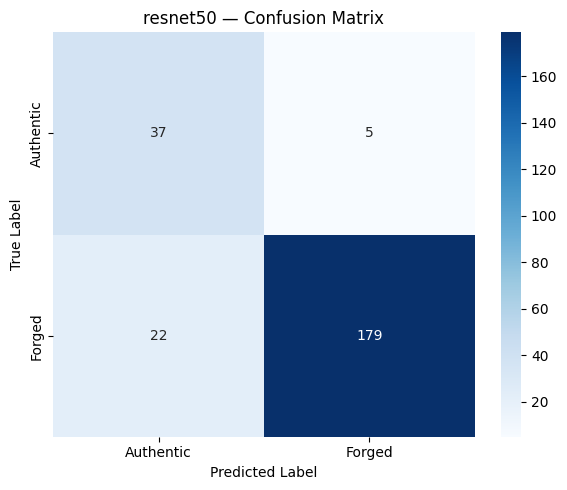

Saved: /kaggle/working/SusLens_Results/resnet50_confusion_matrix.png


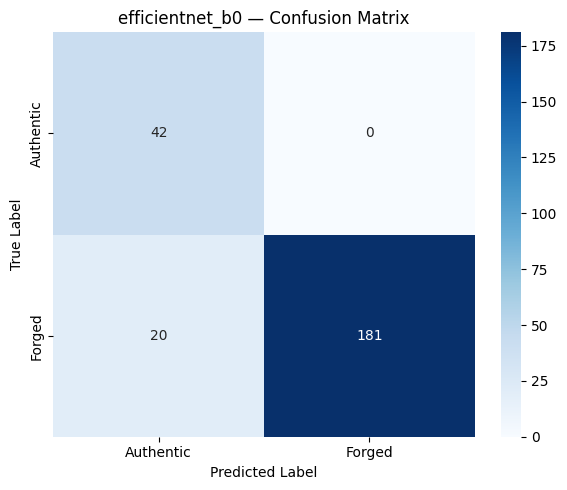

Saved: /kaggle/working/SusLens_Results/efficientnet_b0_confusion_matrix.png


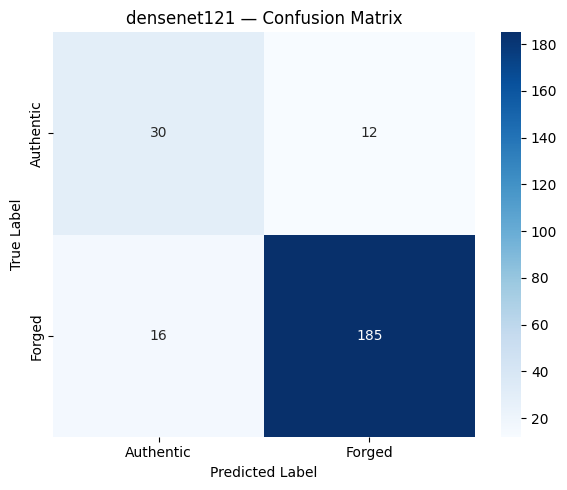

Saved: /kaggle/working/SusLens_Results/densenet121_confusion_matrix.png


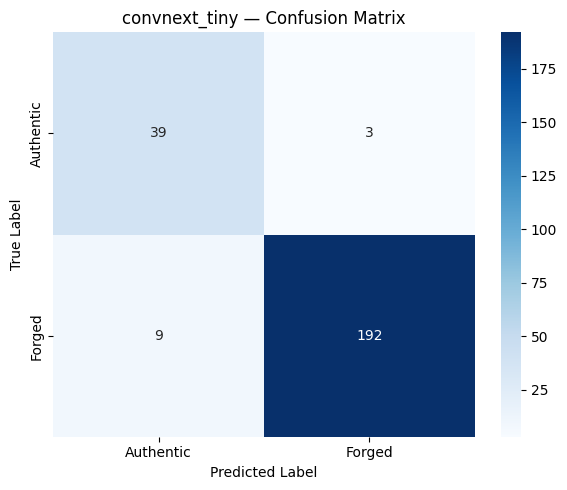

Saved: /kaggle/working/SusLens_Results/convnext_tiny_confusion_matrix.png


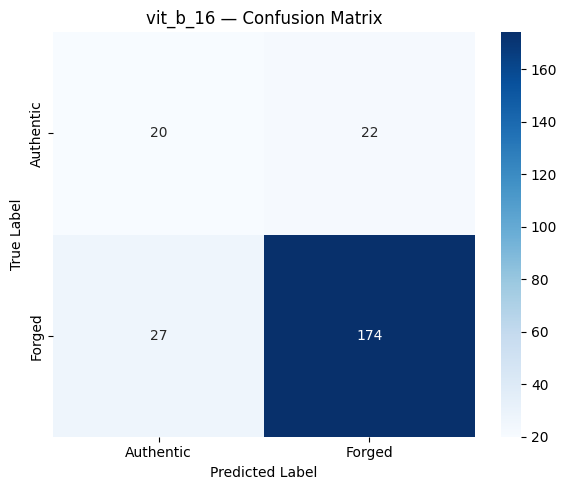

Saved: /kaggle/working/SusLens_Results/vit_b_16_confusion_matrix.png

✅ Confusion-matrix heatmaps generated for all models.


In [31]:
# ============================================================
# SusLens — CONFUSION MATRIX HEATMAPS
# Uses saved image-level evaluation results.
# NO RETRAINING.
# ============================================================

import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_PATH = "/kaggle/working/SusLens_Results"

comparison_file = os.path.join(
    RESULTS_PATH,
    "image_level_model_comparison.json"
)

with open(comparison_file, "r") as f:
    all_results = json.load(f)

for result in all_results:

    model_name = result["model"]
    cm = result["confusion_matrix"]

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Authentic", "Forged"],
        yticklabels=["Authentic", "Forged"]
    )

    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()

    save_path = os.path.join(
        RESULTS_PATH,
        f"{model_name}_confusion_matrix.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {save_path}")

print("\n✅ Confusion-matrix heatmaps generated for all models.")

# ROC Curve + ROC-AUC

In [32]:
# ============================================================
# SusLens — CORRECT IMAGE-LEVEL EVALUATION
# Uses the 2 mask-guided patches belonging to each image.
# NO RETRAINING.
# ============================================================

import os
import json
import numpy as np
import torch
import torch.nn as nn

from torchvision import models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix
)

RESULTS_PATH = "/kaggle/working/SusLens_Results"

CHECKPOINT_PATH = "/kaggle/input/datasets/sabarivasanv1/trained-model-details"

os.makedirs(RESULTS_PATH, exist_ok=True)

PATCHES_PER_IMAGE = 2

model_configs = {
    "resnet50": "resnet50_best.pth",
    "efficientnet_b0": "efficientnet_b0_best.pth",
    "densenet121": "densenet121_best.pth",
    "convnext_tiny": "convnext_tiny_best.pth",
    "vit_b_16": "vit_b_16_best.pth",
}

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


def create_model(model_name):

    if model_name == "resnet50":
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(
            model.fc.in_features,
            2
        )

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            2
        )

    elif model_name == "densenet121":
        model = models.densenet121(weights=None)
        model.classifier = nn.Linear(
            model.classifier.in_features,
            2
        )

    elif model_name == "convnext_tiny":
        model = models.convnext_tiny(weights=None)
        model.classifier[2] = nn.Linear(
            model.classifier[2].in_features,
            2
        )

    elif model_name == "vit_b_16":
        model = models.vit_b_16(weights=None)
        model.heads.head = nn.Linear(
            model.heads.head.in_features,
            2
        )

    return model.to(device)


all_results = []

print("=" * 70)
print("SUSLENS — CORRECT IMAGE-LEVEL EVALUATION")
print("=" * 70)

for model_name, checkpoint_name in model_configs.items():

    print(f"\n🔹 Evaluating {model_name}...")

    checkpoint_path = os.path.join(
        CHECKPOINT_PATH,
        checkpoint_name
    )

    model = create_model(model_name)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict)
    model.eval()

    image_labels = []
    image_scores = []

    # --------------------------------------------------------
    # Each original image has exactly 2 mask-guided patches
    # --------------------------------------------------------

    with torch.no_grad():

        num_images = (
            len(mask_patch_test_dataset)
            // PATCHES_PER_IMAGE
        )

        for image_index in range(num_images):

            start_idx = (
                image_index
                * PATCHES_PER_IMAGE
            )

            end_idx = (
                start_idx
                + PATCHES_PER_IMAGE
            )

            patch_scores = []

            for patch_idx in range(
                start_idx,
                end_idx
            ):

                image, label = (
                    mask_patch_test_dataset[patch_idx]
                )

                image = image.unsqueeze(0).to(device)

                outputs = model(image)

                probabilities = torch.softmax(
                    outputs,
                    dim=1
                )

                forged_probability = (
                    probabilities[0, 1].item()
                )

                patch_scores.append(
                    forged_probability
                )

            # Average the two patch probabilities
            image_score = np.mean(
                patch_scores
            )

            image_label = (
                mask_patch_test_dataset[
                    start_idx
                ][1]
            )

            image_scores.append(
                float(image_score)
            )

            image_labels.append(
                int(image_label)
            )

    image_scores = np.array(image_scores)
    image_labels = np.array(image_labels)

    # --------------------------------------------------------
    # Image-level prediction
    # --------------------------------------------------------

    image_predictions = (
        image_scores >= 0.5
    ).astype(int)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        image_labels,
        image_predictions
    )

    precision = precision_score(
        image_labels,
        image_predictions,
        zero_division=0
    )

    recall = recall_score(
        image_labels,
        image_predictions,
        zero_division=0
    )

    f1 = f1_score(
        image_labels,
        image_predictions,
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        image_labels,
        image_predictions
    )

    roc_auc = roc_auc_score(
        image_labels,
        image_scores
    )

    cm = confusion_matrix(
        image_labels,
        image_predictions
    )

    result = {
        "model": model_name,

        "accuracy": float(accuracy),

        "precision": float(precision),

        "forged_recall": float(recall),

        "f1": float(f1),

        "balanced_accuracy": float(
            balanced_acc
        ),

        "roc_auc": float(
            roc_auc
        ),

        "confusion_matrix": cm.tolist(),

        "image_labels": image_labels.tolist(),

        "image_scores": image_scores.tolist()
    }

    all_results.append(result)

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Forged Recall     : {recall:.4f}")
    print(f"F1 Score          : {f1:.4f}")
    print(f"Balanced Accuracy : {balanced_acc:.4f}")
    print(f"ROC-AUC           : {roc_auc:.4f}")

    print("Confusion Matrix:")
    print(cm)

    del model
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

comparison_file = os.path.join(
    RESULTS_PATH,
    "image_level_model_comparison.json"
)

with open(
    comparison_file,
    "w"
) as f:

    json.dump(
        all_results,
        f,
        indent=4
    )


print("\n" + "=" * 70)
print("CORRECT IMAGE-LEVEL COMPARISON")
print("=" * 70)

for result in all_results:

    print(
        f"{result['model']:20s} | "
        f"Acc: {result['accuracy']:.4f} | "
        f"F1: {result['f1']:.4f} | "
        f"Recall: {result['forged_recall']:.4f} | "
        f"AUC: {result['roc_auc']:.4f}"
    )

print("\n✅ Saved:")
print(comparison_file)

SUSLENS — CORRECT IMAGE-LEVEL EVALUATION

🔹 Evaluating resnet50...
Accuracy          : 0.8848
Precision         : 0.9676
Forged Recall     : 0.8905
F1 Score          : 0.9275
Balanced Accuracy : 0.8738
ROC-AUC           : 0.9507
Confusion Matrix:
[[ 36   6]
 [ 22 179]]

🔹 Evaluating efficientnet_b0...
Accuracy          : 0.9136
Precision         : 0.9945
Forged Recall     : 0.9005
F1 Score          : 0.9452
Balanced Accuracy : 0.9383
ROC-AUC           : 0.9681
Confusion Matrix:
[[ 41   1]
 [ 20 181]]

🔹 Evaluating densenet121...
Accuracy          : 0.8848
Precision         : 0.9391
Forged Recall     : 0.9204
F1 Score          : 0.9296
Balanced Accuracy : 0.8173
ROC-AUC           : 0.9161
Confusion Matrix:
[[ 30  12]
 [ 16 185]]

🔹 Evaluating convnext_tiny...
Accuracy          : 0.9383
Precision         : 0.9697
Forged Recall     : 0.9552
F1 Score          : 0.9624
Balanced Accuracy : 0.9062
ROC-AUC           : 0.9711
Confusion Matrix:
[[ 36   6]
 [  9 192]]

🔹 Evaluating vit_b_16...
Ac

# Cell 1 — ROC Curve + ROC-AUC

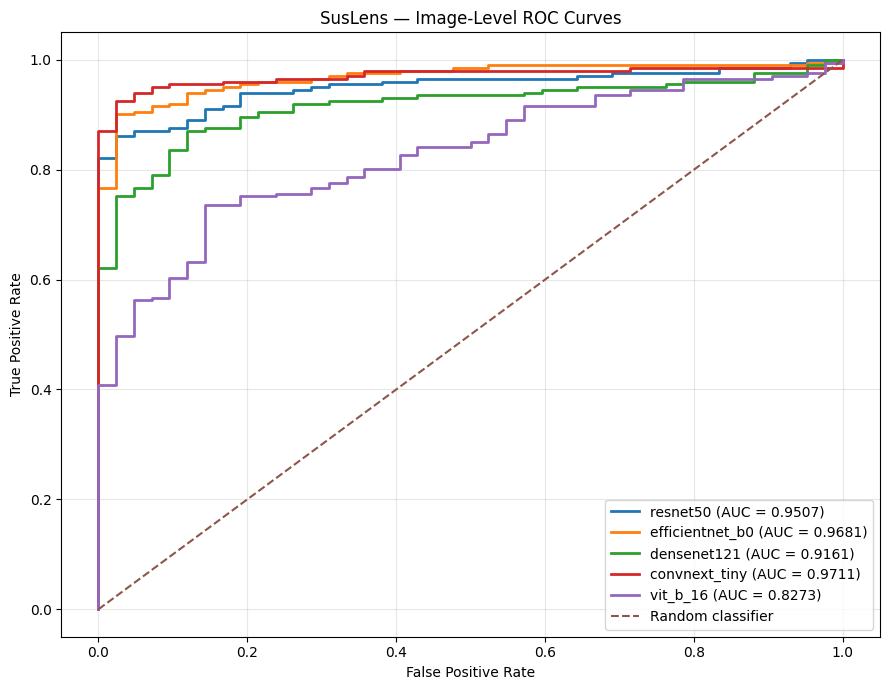

ROC curve saved:
/kaggle/working/SusLens_Results/image_level_roc_curves.png


In [33]:
# ============================================================
# SusLens — ROC CURVE + ROC-AUC
# Uses saved image-level evaluation results
# NO TRAINING
# ============================================================

import os
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

RESULTS_PATH = "/kaggle/working/SusLens_Results"

comparison_file = os.path.join(
    RESULTS_PATH,
    "image_level_model_comparison.json"
)

with open(comparison_file, "r") as f:
    all_results = json.load(f)

plt.figure(figsize=(9, 7))

for result in all_results:

    labels = np.array(result["image_labels"])
    scores = np.array(result["image_scores"])

    fpr, tpr, _ = roc_curve(
        labels,
        scores
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{result['model']} (AUC = {roc_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "SusLens — Image-Level ROC Curves"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.tight_layout()

roc_path = os.path.join(
    RESULTS_PATH,
    "image_level_roc_curves.png"
)

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved:")
print(roc_path)

# Cell 2 — Metrics CSV

In [35]:
# ============================================================
# SusLens — SAVE IMAGE-LEVEL METRICS TO CSV
# ============================================================

import os
import json
import pandas as pd

RESULTS_PATH = "/kaggle/working/SusLens_Results"

comparison_file = os.path.join(
    RESULTS_PATH,
    "image_level_model_comparison.json"
)

with open(comparison_file, "r") as f:
    all_results = json.load(f)

rows = []

for result in all_results:

    rows.append({
        "Model": result["model"],
        "Accuracy": result["accuracy"],
        "Precision": result["precision"],
        "Forged Recall": result["forged_recall"],
        "F1 Score": result["f1"],
        "Balanced Accuracy": result["balanced_accuracy"],
        "ROC-AUC": result["roc_auc"]
    })

metrics_df = pd.DataFrame(rows)

csv_path = os.path.join(
    RESULTS_PATH,
    "image_level_metrics.csv"
)

metrics_df.to_csv(
    csv_path,
    index=False
)

print("Image-level metrics:")
display(metrics_df)

print("\nCSV saved:")
print(csv_path)

Image-level metrics:


,Model,Accuracy,Precision,Forged Recall,F1 Score,Balanced Accuracy,ROC-AUC
0,resnet50,0.884774,0.967568,0.890547,0.927461,0.873845,0.950723
1,efficientnet_b0,0.913580,0.994505,0.900498,0.945170,0.938344,0.968136
2,densenet121,0.884774,0.939086,0.920398,0.929648,0.817342,0.916134
3,convnext_tiny,0.938272,0.969697,0.955224,0.962406,0.906183,0.971097
4,vit_b_16,0.794239,0.883249,0.865672,0.874372,0.659026,0.827292



CSV saved:
/kaggle/working/SusLens_Results/image_level_metrics.csv


# Cell 3 — Model ranking

In [36]:
# ============================================================
# SusLens — MODEL COMPARISON
# ============================================================

ranking_df = metrics_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

print("IMAGE-LEVEL MODEL RANKING")
print("=" * 70)

display(ranking_df)

best_model = ranking_df.iloc[0]["Model"]

print(f"\nCurrent best candidate: {best_model}")

IMAGE-LEVEL MODEL RANKING


,Model,Accuracy,Precision,Forged Recall,F1 Score,Balanced Accuracy,ROC-AUC
0,convnext_tiny,0.938272,0.969697,0.955224,0.962406,0.906183,0.971097
1,efficientnet_b0,0.913580,0.994505,0.900498,0.945170,0.938344,0.968136
2,densenet121,0.884774,0.939086,0.920398,0.929648,0.817342,0.916134
3,resnet50,0.884774,0.967568,0.890547,0.927461,0.873845,0.950723
4,vit_b_16,0.794239,0.883249,0.865672,0.874372,0.659026,0.827292



Current best candidate: convnext_tiny


# Grad-CAM for ConvNeXt-Tiny

In [37]:
# ============================================================
# SusLens — Inspect ConvNeXt-Tiny Layers for Grad-CAM
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.convnext_tiny(weights=None)

model.classifier[2] = nn.Linear(
    model.classifier[2].in_features,
    2
)

model = model.to(device)

print("ConvNeXt-Tiny feature layers:")
print("=" * 60)

for name, module in model.features.named_modules():
    if isinstance(module, nn.Conv2d):
        print(name, "->", module)

ConvNeXt-Tiny feature layers:
0.0 -> Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
1.0.block.0 -> Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
1.1.block.0 -> Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
1.2.block.0 -> Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
2.1 -> Conv2d(96, 192, kernel_size=(2, 2), stride=(2, 2))
3.0.block.0 -> Conv2d(192, 192, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=192)
3.1.block.0 -> Conv2d(192, 192, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=192)
3.2.block.0 -> Conv2d(192, 192, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=192)
4.1 -> Conv2d(192, 384, kernel_size=(2, 2), stride=(2, 2))
5.0.block.0 -> Conv2d(384, 384, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=384)
5.1.block.0 -> Conv2d(384, 384, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=384)
5.2.block.0 -> Conv2d(384, 384, kernel_size=(7

# Actual Grad-CAM generation cell.

Device: cuda
ConvNeXt-Tiny checkpoint loaded successfully.
Grad-CAM target layer:
Conv2d(768, 768, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=768)

GRAD-CAM PREDICTION
Predicted class : Forged
Confidence      : 0.9951

Class probabilities:
Authentic : 0.0049
Forged    : 0.9951

Activation shape: torch.Size([1, 768, 7, 7])
Gradient shape  : torch.Size([1, 768, 7, 7])


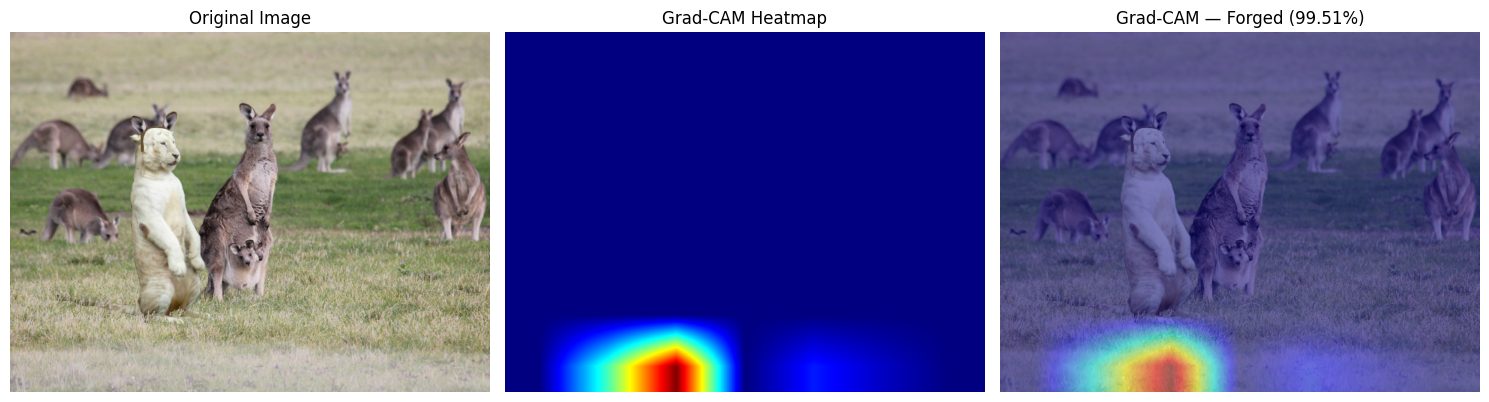


Grad-CAM completed successfully.


In [38]:
# ============================================================
# SUSLENS — GRAD-CAM VISUALIZATION FOR CONVNEXT-TINY
# ============================================================

import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

CHECKPOINT_PATH = (
    "/kaggle/input/datasets/sabarivasanv1/"
    "trained-model-details/convnext_tiny_best.pth"
)

image_path = (
    "/kaggle/input/datasets/saikotahmed/imd2020/"
    "IMD2020/img/c8tzqf0_0.jpg"
)

# ------------------------------------------------------------
# 2. Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# ------------------------------------------------------------
# 3. Load ConvNeXt-Tiny
# ------------------------------------------------------------

model = models.convnext_tiny(weights=None)

# Change classifier for our binary task
model.classifier[2] = nn.Linear(
    model.classifier[2].in_features,
    2
)

# Load trained checkpoint
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print("ConvNeXt-Tiny checkpoint loaded successfully.")

# ------------------------------------------------------------
# 4. Select Grad-CAM target layer
# ------------------------------------------------------------

target_layer = model.features[7][2].block[0]

print("Grad-CAM target layer:")
print(target_layer)

# ------------------------------------------------------------
# 5. Store activations and gradients
# ------------------------------------------------------------

activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

forward_handle = target_layer.register_forward_hook(
    forward_hook
)

backward_handle = target_layer.register_full_backward_hook(
    backward_hook
)

# ------------------------------------------------------------
# 6. Image preprocessing
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

original_image = Image.open(image_path).convert("RGB")

input_tensor = transform(
    original_image
).unsqueeze(0).to(device)

# ------------------------------------------------------------
# 7. Forward pass
# ------------------------------------------------------------

model.zero_grad()

output = model(input_tensor)

probabilities = torch.softmax(output, dim=1)

predicted_class = output.argmax(dim=1).item()

confidence = probabilities[
    0, predicted_class
].item()

class_name = (
    "Forged"
    if predicted_class == 1
    else "Authentic"
)

print()
print("=" * 60)
print("GRAD-CAM PREDICTION")
print("=" * 60)
print("Predicted class :", class_name)
print("Confidence      :", f"{confidence:.4f}")

print()
print("Class probabilities:")
print("Authentic :", f"{probabilities[0,0].item():.4f}")
print("Forged    :", f"{probabilities[0,1].item():.4f}")

# ------------------------------------------------------------
# 8. Backward pass
# ------------------------------------------------------------

score = output[0, predicted_class]

score.backward()

# ------------------------------------------------------------
# 9. Get activations and gradients
# ------------------------------------------------------------

activation = activations[0].detach()
gradient = gradients[0].detach()

print()
print("Activation shape:", activation.shape)
print("Gradient shape  :", gradient.shape)

# ------------------------------------------------------------
# 10. Calculate Grad-CAM
# ------------------------------------------------------------

# Average gradients across spatial dimensions
weights = gradient.mean(
    dim=(2, 3),
    keepdim=True
)

# Weighted combination of feature maps
cam = (
    weights * activation
).sum(dim=1).squeeze(0)

# Keep only positive influence
cam = torch.relu(cam)

# Normalize between 0 and 1
cam -= cam.min()

if cam.max() > 0:
    cam /= cam.max()

cam = cam.cpu().numpy()

# ------------------------------------------------------------
# 11. Resize CAM to original image size
# ------------------------------------------------------------

original_np = np.array(original_image)

height, width = original_np.shape[:2]

cam = cv2.resize(
    cam,
    (width, height)
)

# ------------------------------------------------------------
# 12. Create heatmap
# ------------------------------------------------------------

heatmap = np.uint8(
    255 * cam
)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(
    heatmap,
    cv2.COLOR_BGR2RGB
)

# ------------------------------------------------------------
# 13. Create overlay
# ------------------------------------------------------------

overlay = (
    0.5 * original_np +
    0.5 * heatmap
).astype(np.uint8)

# ------------------------------------------------------------
# 14. Display results
# ------------------------------------------------------------

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(
    f"Grad-CAM — {class_name} ({confidence:.2%})"
)
plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 15. Remove hooks
# ------------------------------------------------------------

forward_handle.remove()
backward_handle.remove()

print()
print("Grad-CAM completed successfully.")

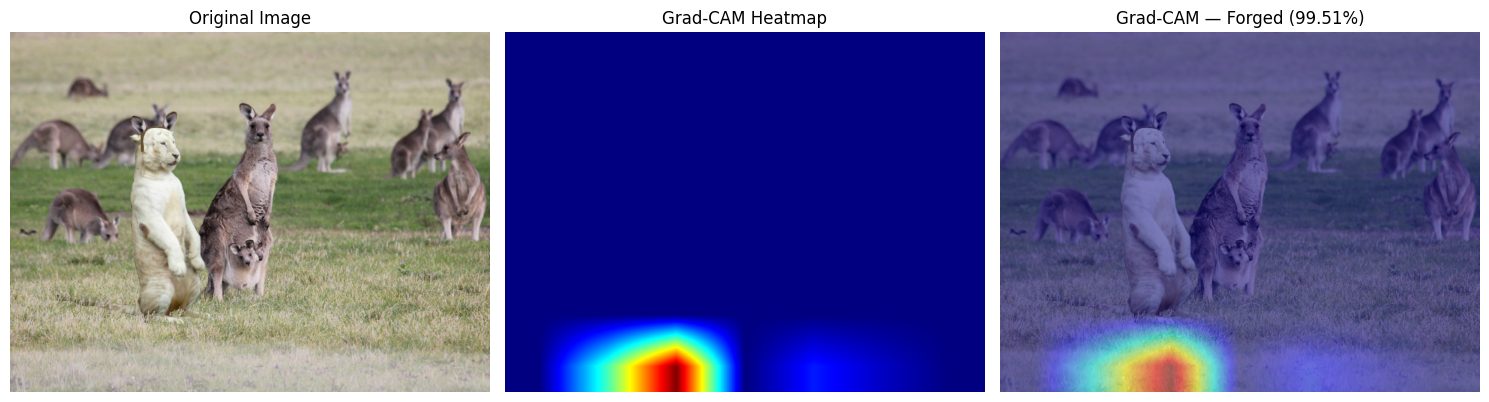

Grad-CAM saved successfully.
Path: /kaggle/working/SusLens_Results/convnext_tiny_gradcam.png


In [39]:
# ============================================================
# SUSLENS — SAVE GRAD-CAM RESULT
# ============================================================

import os
import matplotlib.pyplot as plt

RESULTS_PATH = "/kaggle/working/SusLens_Results"

os.makedirs(RESULTS_PATH, exist_ok=True)

save_path = os.path.join(
    RESULTS_PATH,
    "convnext_tiny_gradcam.png"
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(
    f"Grad-CAM — {class_name} ({confidence:.2%})"
)
plt.axis("off")

plt.tight_layout()

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 60)
print("Grad-CAM saved successfully.")
print("=" * 60)
print("Path:", save_path)

# Final model download


In [42]:
# ============================================================
# SUSLENS — ORGANISE FINAL RESULT BUNDLE
# ============================================================

import os
import shutil

SOURCE = "/kaggle/working/SusLens_Results"
ORG = "/kaggle/working/SusLens_Final_Results"

# Remove old organised folder if it exists
if os.path.exists(ORG):
    shutil.rmtree(ORG)

# Create organised structure
folders = [
    "01_Model_Comparison",
    "02_Image_Level_Evaluation",
    "03_ROC_and_Metrics",
    "04_Explainability",
    "05_Checkpoints",
    "06_Other_Results"
]

for folder in folders:
    os.makedirs(os.path.join(ORG, folder), exist_ok=True)


def move_if_exists(filename, folder):
    src = os.path.join(SOURCE, filename)
    dst = os.path.join(ORG, folder, filename)

    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"✓ {filename} → {folder}")


# ------------------------------------------------------------
# 1. MODEL COMPARISON
# ------------------------------------------------------------

move_if_exists(
    "image_level_model_comparison.json",
    "01_Model_Comparison"
)

move_if_exists(
    "image_level_metrics.csv",
    "01_Model_Comparison"
)


# ------------------------------------------------------------
# 2. IMAGE-LEVEL EVALUATION
# ------------------------------------------------------------

for filename in os.listdir(SOURCE):
    lower = filename.lower()

    if (
        "image_level" in lower
        and filename not in [
            "image_level_model_comparison.json",
            "image_level_metrics.csv"
        ]
    ):
        move_if_exists(filename, "02_Image_Level_Evaluation")


# ------------------------------------------------------------
# 3. ROC + METRICS
# ------------------------------------------------------------

for filename in os.listdir(SOURCE):
    lower = filename.lower()

    if any(x in lower for x in [
        "roc",
        "metric",
        "confusion",
        "classification"
    ]):
        destination = "03_ROC_and_Metrics"

        # Don't duplicate the main comparison files
        if filename not in [
            "image_level_model_comparison.json",
            "image_level_metrics.csv"
        ]:
            move_if_exists(filename, destination)


# ------------------------------------------------------------
# 4. EXPLAINABILITY
# ------------------------------------------------------------

move_if_exists(
    "convnext_tiny_gradcam.png",
    "04_Explainability"
)


# ------------------------------------------------------------
# 5. CHECKPOINTS
# ------------------------------------------------------------

for filename in os.listdir(SOURCE):
    lower = filename.lower()

    if lower.endswith((".pth", ".pt", ".pth.tar")):
        move_if_exists(filename, "05_Checkpoints")


# ------------------------------------------------------------
# 6. EVERYTHING ELSE
# ------------------------------------------------------------

already_categorized = set()

for root, dirs, files in os.walk(ORG):
    for filename in files:
        already_categorized.add(filename)

for filename in os.listdir(SOURCE):
    src = os.path.join(SOURCE, filename)

    if os.path.isfile(src) and filename not in already_categorized:
        shutil.copy2(
            src,
            os.path.join(ORG, "06_Other_Results", filename)
        )
        print(f"✓ {filename} → 06_Other_Results")


# ------------------------------------------------------------
# CREATE README
# ------------------------------------------------------------

readme = """SUSLENS — FINAL ML RESULT BUNDLE

Project:
SusLens — An Explainable Deep Learning Platform for
Detecting Tampered and AI-Generated Images

Current selected model:
ConvNeXt-Tiny

Evaluation:
- Patch-level model comparison
- Image-level evaluation
- Confusion matrices
- ROC-AUC comparison
- Grad-CAM explainability

Important evaluation limitation:
The image-level experiment used mask-guided patch selection.
Therefore, these results represent a controlled internal evaluation
and should not be presented as unrestricted real-world performance.

Folder structure:

01_Model_Comparison/
    Main model comparison results

02_Image_Level_Evaluation/
    Image-level evaluation artifacts

03_ROC_and_Metrics/
    ROC, confusion matrix and metric artifacts

04_Explainability/
    Grad-CAM visualization

05_Checkpoints/
    Saved model checkpoints

06_Other_Results/
    Remaining experimental artifacts
"""

with open(
    os.path.join(ORG, "README.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)


# ------------------------------------------------------------
# FINAL ZIP
# ------------------------------------------------------------

ZIP_BASE = "/kaggle/working/SusLens_Final_Results"

zip_path = shutil.make_archive(
    ZIP_BASE,
    "zip",
    ORG
)

size_mb = os.path.getsize(zip_path) / (1024 * 1024)

print("\n" + "=" * 60)
print("SUSLENS RESULT BUNDLE ORGANIZED")
print("=" * 60)
print("Folder :", ORG)
print("ZIP    :", zip_path)
print(f"Size   : {size_mb:.2f} MB")

print("\nContents:")
for root, dirs, files in os.walk(ORG):
    level = root.replace(ORG, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}    {file}")

✓ image_level_model_comparison.json → 01_Model_Comparison
✓ image_level_metrics.csv → 01_Model_Comparison
✓ image_level_roc_curves.png → 02_Image_Level_Evaluation
✓ densenet121_confusion_matrix.png → 03_ROC_and_Metrics
✓ resnet50_confusion_matrix.png → 03_ROC_and_Metrics
✓ vit_b_16_confusion_matrix.png → 03_ROC_and_Metrics
✓ image_level_roc_curves.png → 03_ROC_and_Metrics
✓ efficientnet_b0_confusion_matrix.png → 03_ROC_and_Metrics
✓ convnext_tiny_confusion_matrix.png → 03_ROC_and_Metrics
✓ convnext_tiny_gradcam.png → 04_Explainability

SUSLENS RESULT BUNDLE ORGANIZED
Folder : /kaggle/working/SusLens_Final_Results
ZIP    : /kaggle/working/SusLens_Final_Results.zip
Size   : 4.06 MB

Contents:
SusLens_Final_Results/
    README.txt
    02_Image_Level_Evaluation/
        image_level_roc_curves.png
    04_Explainability/
        convnext_tiny_gradcam.png
    03_ROC_and_Metrics/
        densenet121_confusion_matrix.png
        resnet50_confusion_matrix.png
        vit_b_16_confusion_matrix.pn

# SusLens
## An Explainable Deep Learning Platform for Detecting Tampered and AI-Generated Images

> **"If it's sus, we'll show you why."**

### Machine Learning Module — Final Experimental Notebook

This notebook documents the machine learning component of **SusLens**.

The current ML task is:

**Binary image classification**
- `0` → Authentic
- `1` → Forged

The experiment uses the **IMD2020 dataset** and compares five pretrained deep-learning architectures:

1. ResNet50
2. EfficientNet-B0
3. DenseNet121
4. ConvNeXt-Tiny
5. ViT-B/16

The notebook covers:

- Dataset inspection and preparation
- Class-imbalance handling
- Patch-based training
- Model comparison
- Image-level evaluation
- Confusion matrices
- ROC-AUC analysis
- Grad-CAM explainability
- Final model selection

### Current selected model

**ConvNeXt-Tiny**

In the current mask-guided image-level evaluation on the internal test split, ConvNeXt-Tiny achieved:

- Accuracy: **93.83%**
- Precision: **96.97%**
- Forged Recall: **95.52%**
- F1 Score: **96.24%**
- Balanced Accuracy: **90.62%**
- ROC-AUC: **0.9711**

> **Important experimental note:**  
> The current image-level evaluation uses ground-truth masks to guide suspicious patch selection. Therefore, these results represent a controlled internal experiment and should not be interpreted as unrestricted real-world deployment performance.

## Notebook Status

This notebook contains the completed ML experiments for the current SusLens project.

No additional model training is required at this stage.

The next development phase is integration of the selected model into the SusLens FastAPI backend and React frontend.